<a href="https://colab.research.google.com/github/huinansky/ISE_Taks1/blob/main/ISE_Taks1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
########## Import required libraries ##########

import pandas as pd
import numpy as np
import re
import math
import os
import subprocess

import time

# Text and feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation and tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)

# Classifier
from sklearn.naive_bayes import GaussianNB

# Text cleaning & stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sentence_transformers import SentenceTransformer

from sklearn.svm import SVC

import ast
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

import glob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
########## Define text preprocessing methods ##########

def remove_html(text):
    """Remove HTML tags using a regex."""
    html = re.compile(r'<.*?>')
    return html.sub(r'', text)

def remove_emoji(text):
    """Remove emojis using a regex pattern."""
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"  # enclosed characters
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# Stopwords
NLTK_stop_words_list = stopwords.words('english')
custom_stop_words_list = ['...']  # You can customize this list as needed
final_stop_words_list = NLTK_stop_words_list + custom_stop_words_list

def remove_stopwords(text):
    """Remove stopwords from the text."""
    return " ".join([word for word in str(text).split() if word not in final_stop_words_list])

def clean_str(string):
    """
    Clean text by removing non-alphanumeric characters,
    and convert it to lowercase.
    """
    string = re.sub(r'0x[0-9a-fA-F]+', ' ', string)
    string = re.sub(r"[^A-Za-z0-9(),.!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"\)", " ) ", string)
    string = re.sub(r"\?", " ? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\\", "", string)
    string = re.sub(r"\'", "", string)
    string = re.sub(r"\"", "", string)
    return string.strip().lower()

In [19]:
########## Load and Clean Data ##########

project = 'pytorch'
# project = 'caffe'
# project = 'incubator-mxnet'
# project = 'keras'
# project = 'tensorflow'

url = f'https://raw.githubusercontent.com/ideas-labo/ise-lab-solution/main/lab1/datasets/{project}.csv'

print(f"Start Read {url}")
pd_all = pd.read_csv(url)
pd_all = pd_all.sample(frac=1, random_state=999)  # Shuffle

# Concatenate title and body
pd_all['Title+Body'] = pd_all.apply(
    lambda row: row['Title'] + '. ' + row['Body'] if pd.notna(row['Body']) else row['Title'],
    axis=1
)

# Rename columns
data = pd_all.rename(columns={"class": "label", "Title+Body": "text"})
data = data[["label", "text"]].fillna('')

print("Start cleaning the data....")
text_col = 'text'
data[text_col] = data[text_col].apply(remove_html)
data[text_col] = data[text_col].apply(remove_emoji)
data[text_col] = data[text_col].apply(remove_stopwords)
data[text_col] = data[text_col].apply(clean_str)

print("Data cleaning completed")

Start Read https://raw.githubusercontent.com/ideas-labo/ise-lab-solution/main/lab1/datasets/pytorch.csv
Start cleaning the data....
Data cleaning completed


In [20]:
########## Evaluation Metrics Function ##########
def get_metrics(model, X_test, y_test):

    # 1. Discrete prediction
    y_pred = model.predict(X_test)

    # 2. Probability prediction
    y_probs = model.predict_proba(X_test)[:, 1]

    # 3. Calculate standard metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1  = f1_score(y_test, y_pred, average='macro')

    # 4. Calculate AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs, pos_label=1)
    roc_auc = auc(fpr, tpr)

    return acc, pre, rec, f1, roc_auc


In [21]:
########## TF-IDF + GNB ##########

# Key Configurations
REPEAT = 30
TEST_SIZE = 0.3

out_csv_name = f'{project}_TFIDF_GNB_Results.csv'

text_col = 'text'

# Hyperparameter grid
params = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

# Lists to store metrics across repeated runs
accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f"Starting {REPEAT} evaluation loops (TF-IDF + GNB)...")

for repeated_time in range(REPEAT):
    start_run = time.time() # Record start time

    # Split into train/test
    indices = np.arange(data.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    train_text = data[text_col].iloc[train_index]
    test_text  = data[text_col].iloc[test_index]

    y_train = data['label'].iloc[train_index]
    y_test  = data['label'].iloc[test_index]

    # Feature Extraction
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=1000
    )
    # sparse matrix representations
    X_train_sparse = tfidf.fit_transform(train_text)
    X_test_sparse = tfidf.transform(test_text)

    # Convert sparse matrices to dense arrays to ensure compatibility with GaussianNB
    X_train = X_train_sparse.toarray()
    X_test = X_test_sparse.toarray()

    # Classifier & GridSearch
    clf = GaussianNB()
    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    # Retrieve the best model
    best_clf = grid.best_estimator_

    # Make predictions & evaluate
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metric
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# Aggregate results
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall  = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== TF-IDF + GaussianNB ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:     {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:         {avg_duration:.4f}")

# Save final results to CSV
header_needed = not os.path.exists(out_csv_name)

df_log = pd.DataFrame(
    {
        'repeated_times': [REPEAT],
        'Accuracy': [final_accuracy],
        'Precision': [final_precision],
        'Recall': [final_recall],
        'F1': [final_f1],
        'AUC': [final_auc],
        'CV_list(AUC)': [str(auc_values)],
        'CV_list(F1)': [str(f1_scores)],
        'Avg_Time_Sec': [avg_duration]
    }
)

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

Starting 30 evaluation loops (TF-IDF + GNB)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== TF-IDF + GaussianNB ===
Number of repeats:     30
Average Accuracy:      0.6364
Average Precision:     0.6108
Average Recall:        0.7547
Average F1 score:      0.5615
Average AUC:           0.8454
Average Duration:         1.5920

 Results saved to: pytorch_TFIDF_GNB_Results.csv


In [22]:
########## TF-IDF + MLP ##########

# Key Configurations
REPEAT = 30
TEST_SIZE = 0.3

out_csv_name = f'{project}_TFIDF_MLP_Results.csv'

text_col = 'text'

# Hyperparameter grid
params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'alpha': [0.0001, 0.001]
}


# Lists to store metrics across repeated runs
accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f"Starting {REPEAT} evaluation loops (TF-IDF + MLP)...")

for repeated_time in range(REPEAT):
    start_run = time.time() # Record start time
    # Split into train/test
    indices = np.arange(data.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    train_text = data[text_col].iloc[train_index]
    test_text  = data[text_col].iloc[test_index]

    y_train = data['label'].iloc[train_index]
    y_test  = data['label'].iloc[test_index]

    # Feature Extraction
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=1000
    )
    # sparse matrix representations
    X_train_sparse = tfidf.fit_transform(train_text)
    X_test_sparse = tfidf.transform(test_text)

    # Convert sparse matrices to dense arrays to ensure compatibility with GaussianNB
    X_train = X_train_sparse.toarray()
    X_test = X_test_sparse.toarray()


    # Classifier & GridSearch
    clf = MLPClassifier(random_state=42, max_iter=500)
    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )


    grid.fit(X_train, y_train)

    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    best_clf = grid.best_estimator_

    # Make predictions & evaluate ---
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metrics
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# Aggregate results
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall    = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== TF-IDF + MLP ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:      {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:        {avg_duration:.4f}")

header_needed = not os.path.exists(out_csv_name)
df_log = pd.DataFrame({
    'repeated_times': [REPEAT],
    'Accuracy': [final_accuracy],
    'Precision': [final_precision],
    'Recall': [final_recall],
    'F1': [final_f1],
    'AUC': [final_auc],
    'CV_list(AUC)': [str(auc_values)],
    'CV_list(F1)': [str(f1_scores)],
    'Avg_Time_Sec': [avg_duration]
})

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

Starting 30 evaluation loops (TF-IDF + MLP)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== TF-IDF + MLP ===
Number of repeats:     30
Average Accuracy:      0.8760
Average Precision:      0.7075
Average Recall:        0.6512
Average F1 score:      0.6676
Average AUC:           0.8163
Average Duration:        51.4084

 Results saved to: pytorch_TFIDF_MLP_Results.csv


In [23]:
########## TF-IDF + SVM ##########

# Key Configurations
REPEAT = 30
TEST_SIZE = 0.3

out_csv_name = f'{project}_TFIDF_SVM_Results.csv'

text_col = 'text'

# Hyperparameter grid
params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Lists to store metrics across repeated runs
accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f" Starting {REPEAT} evaluation loops (TF-IDF + SVM)...")

for repeated_time in range(REPEAT):
    start_run = time.time() # Record start time
    # Split into train/test
    indices = np.arange(data.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    train_text = data[text_col].iloc[train_index]
    test_text  = data[text_col].iloc[test_index]

    y_train = data['label'].iloc[train_index]
    y_test  = data['label'].iloc[test_index]

    # Feature Extraction
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=1000
    )
    # sparse matrix representations
    X_train_sparse = tfidf.fit_transform(train_text)
    X_test_sparse = tfidf.transform(test_text)

    # Convert sparse matrices to dense arrays to ensure compatibility with GaussianNB
    X_train = X_train_sparse.toarray()
    X_test = X_test_sparse.toarray()


    # Classifier & GridSearch
    clf = SVC(probability=True, random_state=42, class_weight = 'balanced')

    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    best_clf = grid.best_estimator_

    # Make predictions & evaluate
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metrics
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# Aggregate results
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall    = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== TF-IDF + SVM ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:      {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:           {avg_duration:.4f}")

header_needed = not os.path.exists(out_csv_name)
df_log = pd.DataFrame({
    'repeated_times': [REPEAT],
    'Accuracy': [final_accuracy],
    'Precision': [final_precision],
    'Recall': [final_recall],
    'F1': [final_f1],
    'AUC': [final_auc],
    'CV_list(AUC)': [str(auc_values)],
    'CV_list(F1)': [str(f1_scores)],
    'Avg_Time_Sec': [avg_duration]
})

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

 Starting 30 evaluation loops (TF-IDF + SVM)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== TF-IDF + SVM ===
Number of repeats:     30
Average Accuracy:      0.8647
Average Precision:      0.7161
Average Recall:        0.6558
Average F1 score:      0.6553
Average AUC:           0.8531
Average Duration:           11.0139

 Results saved to: pytorch_TFIDF_SVM_Results.csv


In [24]:
########## Extract SBERT Embeddings ##########
print("Loading SBERT model and encoding all text...")
sentences = data['text'].tolist()
y_all = data['label'].values

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_all_embeddings = sbert_model.encode(sentences, show_progress_bar=True)
print("Completed")

Loading SBERT model and encoding all text...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Completed


In [25]:
########## SBERT + GNB ##########

# Key Configurations
REPEAT = 30
TEST_SIZE = 0.3
out_csv_name = f'{project}_SBERT_GNB_Results.csv'
text_col = 'text'

# Hyperparameter grid
params = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f" Starting {REPEAT} evaluation loops (SBERT + GNB)...")

for repeated_time in range(REPEAT):
    start_run = time.time() # Record start time
    # Split into train/test
    indices = np.arange(X_all_embeddings.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    X_train = X_all_embeddings[train_index]
    X_test  = X_all_embeddings[test_index]
    y_train = y_all[train_index]
    y_test  = y_all[test_index]

    # Classifier & GridSearch
    clf = GaussianNB()
    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    best_clf = grid.best_estimator_

    # Make predictions & evaluate
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metrics
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# Aggregate results
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall    = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== SBERT + GNB ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:     {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:           {avg_duration:.4f}")

header_needed = not os.path.exists(out_csv_name)
df_log = pd.DataFrame({
    'repeated_times': [REPEAT],
    'Accuracy': [final_accuracy],
    'Precision': [final_precision],
    'Recall': [final_recall],
    'F1': [final_f1],
    'AUC': [final_auc],
    'CV_list(AUC)': [str(auc_values)],
    'CV_list(F1)': [str(f1_scores)],
    'Avg_Time_Sec': [avg_duration]
})

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

 Starting 30 evaluation loops (SBERT + GNB)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== SBERT + GNB ===
Number of repeats:     30
Average Accuracy:      0.6357
Average Precision:     0.6266
Average Recall:        0.7896
Average F1 score:      0.5700
Average AUC:           0.9403
Average Duration:           0.3721

 Results saved to: pytorch_SBERT_GNB_Results.csv


In [26]:
########## SBERT + MLP ##########
REPEAT = 30
TEST_SIZE = 0.3
out_csv_name = f'{project}_SBERT_MLP_Results.csv'
text_col = 'text'

# Hyperparameter grid
params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'alpha': [0.0001, 0.001]
}

accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f" Starting {REPEAT} evaluation loops (SBERT + MLP)...")

for repeated_time in range(REPEAT):
    start_run = time.time()
    # Split into train/test
    indices = np.arange(X_all_embeddings.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    X_train = X_all_embeddings[train_index]
    X_test  = X_all_embeddings[test_index]
    y_train = y_all[train_index]
    y_test  = y_all[test_index]

    # Classifier & GridSearch
    clf = MLPClassifier(random_state=42, max_iter=500)
    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    best_clf = grid.best_estimator_

    # Make predictions & evaluate
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metrics
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# Aggregate results
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall    = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== SBERT + MLP ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:     {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:           {avg_duration:.4f}")

header_needed = not os.path.exists(out_csv_name)
df_log = pd.DataFrame({
    'repeated_times': [REPEAT],
    'Accuracy': [final_accuracy],
    'Precision': [final_precision],
    'Recall': [final_recall],
    'F1': [final_f1],
    'AUC': [final_auc],
    'CV_list(AUC)': [str(auc_values)],
    'CV_list(F1)': [str(f1_scores)],
    'Avg_Time_Sec': [avg_duration]
})

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

 Starting 30 evaluation loops (SBERT + MLP)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== SBERT + MLP ===
Number of repeats:     30
Average Accuracy:      0.9021
Average Precision:     0.7792
Average Recall:        0.7869
Average F1 score:      0.7772
Average AUC:           0.9261
Average Duration:           24.7199

 Results saved to: pytorch_SBERT_MLP_Results.csv


In [27]:

########## SBERT + SVM ##########
REPEAT = 30
TEST_SIZE = 0.3
out_csv_name = f'{project}_SBERT_SVM_Results.csv'
text_col = 'text'

# Hyperparameter grid
params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

accuracies, precisions, recalls, f1_scores, auc_values, durations = [], [], [], [], [], []

print(f" Starting {REPEAT} evaluation loops (SBERT + SVM)...")

for repeated_time in range(REPEAT):
    start_run = time.time()
    # Split into train/test
    indices = np.arange(X_all_embeddings.shape[0])
    train_index, test_index = train_test_split(
        indices, test_size=TEST_SIZE, random_state=repeated_time
    )

    X_train = X_all_embeddings[train_index]
    X_test  = X_all_embeddings[test_index]
    y_train = y_all[train_index]
    y_test  = y_all[test_index]

    # Classifier & GridSearch
    clf = SVC(probability=True, random_state=42, class_weight = 'balanced')

    grid = GridSearchCV(
        clf,
        params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    end_run = time.time() # Record end time
    durations.append(end_run - start_run) # Record execution duration for the current run

    best_clf = grid.best_estimator_

    # Make predictions & evaluate
    acc, pre, rec, f1_val, roc_auc = get_metrics(best_clf, X_test, y_test)

    # Record evaluation metrics
    accuracies.append(acc)
    precisions.append(pre)
    recalls.append(rec)
    f1_scores.append(f1_val)
    auc_values.append(roc_auc)

    if (repeated_time + 1) % 5 == 0:
        print(f"Completed {repeated_time + 1}/{REPEAT} loops...")

# --- 4.5 Aggregate results ---
final_accuracy  = np.mean(accuracies)
final_precision = np.mean(precisions)
final_recall    = np.mean(recalls)
final_f1        = np.mean(f1_scores)
final_auc       = np.mean(auc_values)
avg_duration = np.mean(durations)

print("\n" + "="*40)
print("=== SBERT + SVM ===")
print("="*40)
print(f"Number of repeats:     {REPEAT}")
print(f"Average Accuracy:      {final_accuracy:.4f}")
print(f"Average Precision:     {final_precision:.4f}")
print(f"Average Recall:        {final_recall:.4f}")
print(f"Average F1 score:      {final_f1:.4f}")
print(f"Average AUC:           {final_auc:.4f}")
print(f"Average Duration:           {avg_duration:.4f}")

header_needed = not os.path.exists(out_csv_name)
df_log = pd.DataFrame({
    'repeated_times': [REPEAT],
    'Accuracy': [final_accuracy],
    'Precision': [final_precision],
    'Recall': [final_recall],
    'F1': [final_f1],
    'AUC': [final_auc],
    'CV_list(AUC)': [str(auc_values)],
    'CV_list(F1)': [str(f1_scores)],
    'Avg_Time_Sec': [avg_duration]
})

df_log.to_csv(out_csv_name, mode='a', header=header_needed, index=False)
print(f"\n Results saved to: {out_csv_name}")

 Starting 30 evaluation loops (SBERT + SVM)...
Completed 5/30 loops...
Completed 10/30 loops...
Completed 15/30 loops...
Completed 20/30 loops...
Completed 25/30 loops...
Completed 30/30 loops...

=== SBERT + SVM ===
Number of repeats:     30
Average Accuracy:      0.8823
Average Precision:     0.7614
Average Recall:        0.8617
Average F1 score:      0.7849
Average AUC:           0.9483
Average Duration:           3.0479

 Results saved to: pytorch_SBERT_SVM_Results.csv


/tmp/ipykernel_876/1956079458.py:23: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  g = sns.catplot(


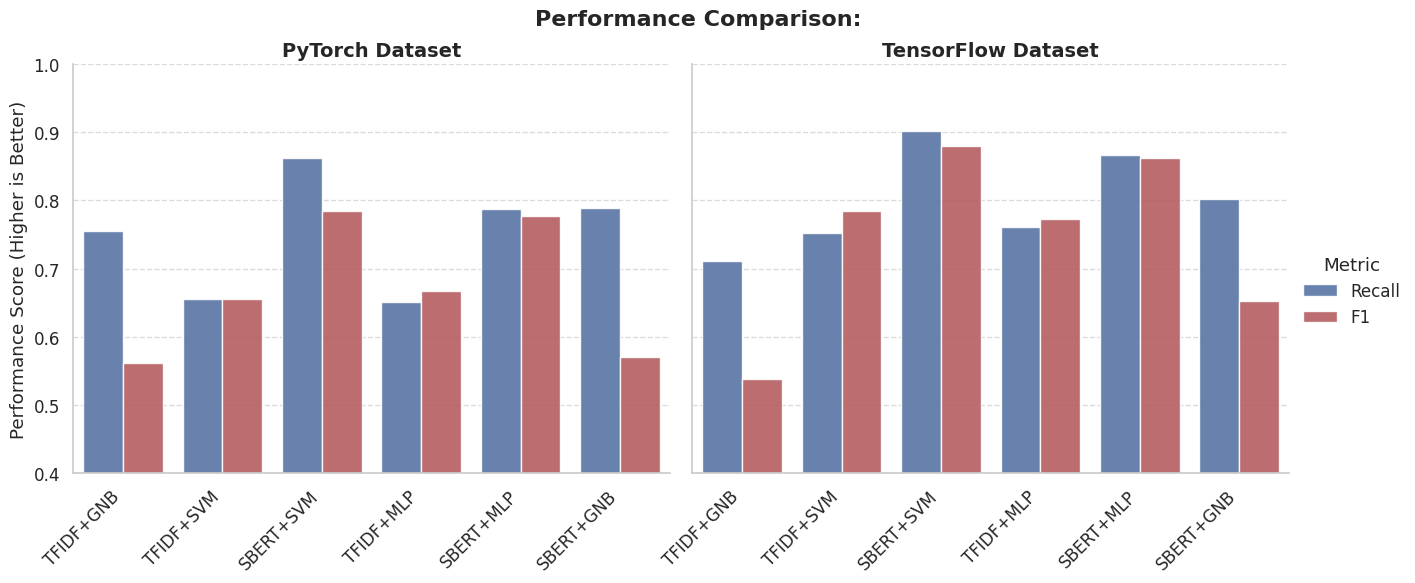

In [31]:
# Merge all CSV results
all_files = glob.glob("*_Results.csv")
df_list = []
for f in all_files:
    temp_df = pd.read_csv(f)
    # Extract project and model names from the filename
    project_name = "PyTorch" if "pytorch" in f.lower() else "TensorFlow"
    model_name = f.split('_')[1] + "+" + f.split('_')[2]

    temp_df['Project'] = project_name
    temp_df['Model'] = model_name
    df_list.append(temp_df)

df_all = pd.concat(df_list)

# Prepare data for plotting
df_plot = df_all.melt(id_vars=['Project', 'Model'],
                      value_vars=['Recall', 'F1'],
                      var_name='Metric', value_name='Score')
# Generate academic plots
sns.set_theme(style="whitegrid", font_scale=1.1)

g = sns.catplot(
    data=df_plot, kind="bar",
    x="Model", y="Score", hue="Metric", col="Project",
    palette=["#4C72B0", "#C44E52"],
    alpha=0.9, height=5.5, aspect=1.2,
    capsize=0.1, errwidth=1.5
)

g.set_axis_labels("", "Performance Score (Higher is Better)")
g.set_titles("{col_name} Dataset", size=14, weight='bold')
g.set_xticklabels(rotation=45, ha="right")

g.set(ylim=(0.4, 1.0))

for ax in g.axes.flat:
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.subplots_adjust(top=0.88)
g.fig.suptitle("Performance Comparison:", fontsize=16, weight='bold')

plt.savefig('Performance_Comparison_Chart.png', dpi=300, bbox_inches='tight')
plt.show()

Match Successful | Dataset: pytorch | Baseline: TF-IDF + GNB
=== Pytorch: TF-IDF + GNB vs SBERT+SVM ===
P-value: 9.3132e-10


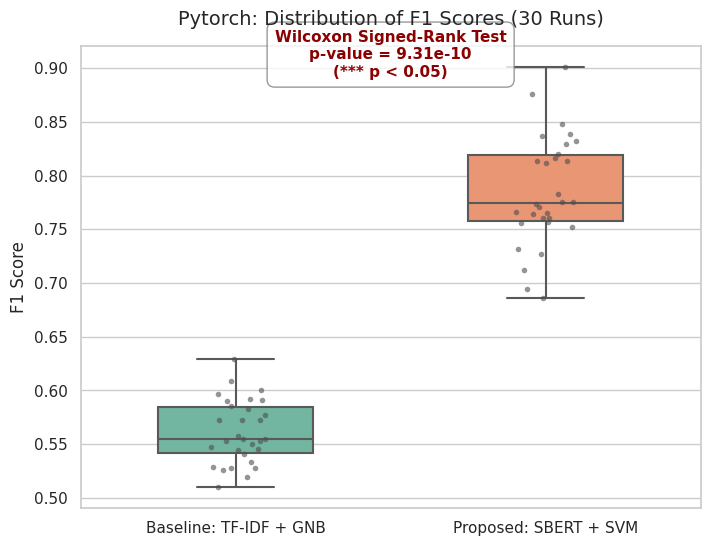

Plot successfully saved as 'pytorch_TFIDF_GNB_vs_SBERTSVM_F1_Boxplot.png'

Match Successful | Dataset: tensorflow | Baseline: TF-IDF + GNB
=== Tensorflow: TF-IDF + GNB vs SBERT+SVM ===
P-value: 9.3132e-10


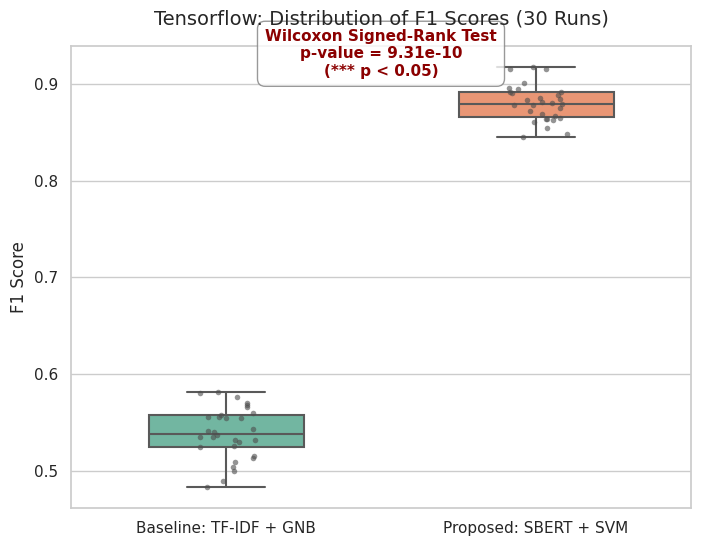

Plot successfully saved as 'tensorflow_TFIDF_GNB_vs_SBERTSVM_F1_Boxplot.png'

Match Successful | Dataset: pytorch | Baseline: SBERT + MLP
=== Pytorch: SBERT + MLP vs SBERT+SVM ===
P-value: 3.0600e-01


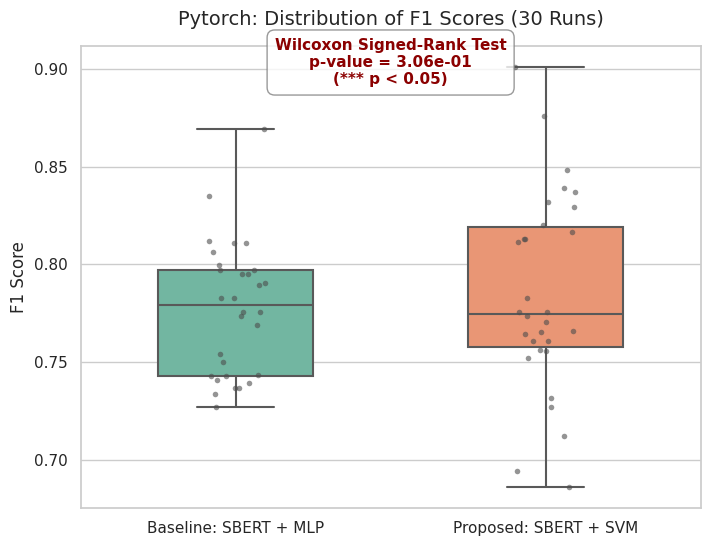

Plot successfully saved as 'pytorch_SBERT_MLP_vs_SBERTSVM_F1_Boxplot.png'

Match Successful | Dataset: tensorflow | Baseline: SBERT + MLP
=== Tensorflow: SBERT + MLP vs SBERT+SVM ===
P-value: 7.9889e-06


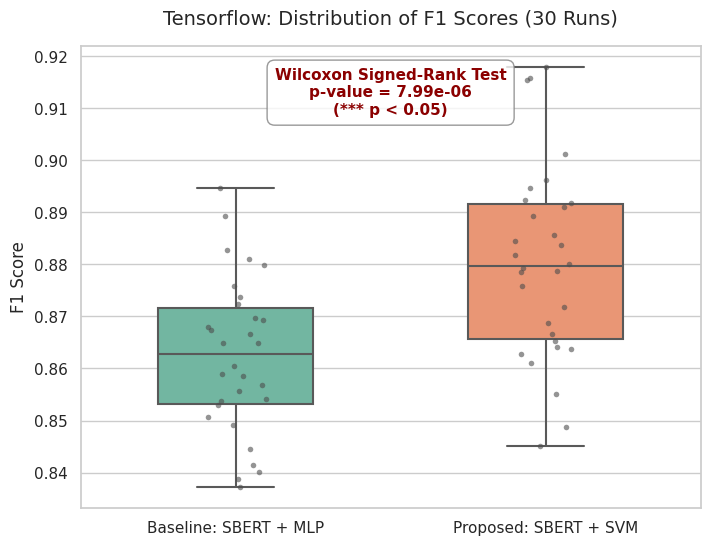

Plot successfully saved as 'tensorflow_SBERT_MLP_vs_SBERTSVM_F1_Boxplot.png'



In [32]:
########## Wilcoxon Statistical Test and Visualization ##########

def get_stats_test_and_plot(baseline_file, proposed_file, dataset_name, baseline_name, metric='AUC'):
    df_base = pd.read_csv(baseline_file)
    df_prop = pd.read_csv(proposed_file)

    list_col = f'CV_list({metric})'

    def clean_and_parse(s):
        s = re.sub(r'np\.\w+\((.*?)\)', r'\1', s)
        s = re.sub(r'array\((.*?)\)', r'\1', s)
        return ast.literal_eval(s)

    try:
        scores_base = clean_and_parse(df_base[list_col].iloc[0])
        scores_prop = clean_and_parse(df_prop[list_col].iloc[0])

        stat, p_value = wilcoxon(scores_prop, scores_base, alternative='greater')
        print(f"=== {dataset_name.capitalize()}: {baseline_name} vs SBERT+SVM ===")
        print(f"P-value: {p_value:.4e}")

        plot_data = pd.DataFrame({
            f'Baseline: {baseline_name}': scores_base,
            'Proposed: SBERT + SVM': scores_prop
        })

        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(8, 6))

        # Draw boxplot
        ax = sns.boxplot(data=plot_data, width=0.5, palette="Set2",
                         linewidth=1.5, fliersize=5)

        sns.stripplot(data=plot_data, size=4, color=".3", linewidth=0, alpha=0.6)

        plt.title(f'{dataset_name.capitalize()}: Distribution of {metric} Scores (30 Runs)', fontsize=14, pad=15)
        plt.ylabel(f'{metric} Score', fontsize=12)
        plt.xticks(fontsize=11)

        significance_text = f"Wilcoxon Signed-Rank Test\np-value = {p_value:.2e}\n(*** p < 0.05)"
        plt.text(0.5, plot_data.max().max() * 0.99, significance_text,
                 horizontalalignment='center', size=11, color='darkred', weight='bold',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

        safe_base_name = baseline_name.replace(" ", "").replace("+", "_").replace("-", "")
        save_name = f'{dataset_name}_{safe_base_name}_vs_SBERTSVM_{metric}_Boxplot.png'

        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Plot successfully saved as '{save_name}'\n")

    except Exception as e:
        print(f"Error parsing CSV format: {e}")


T_BASE = "_TFIDF_GNB_Results.csv"
N_BASE = "_SBERT_MLP_Results.csv"
PROPOSED = "_SBERT_SVM_Results.csv"

baseline_mapping = {
    T_BASE: "TF-IDF + GNB",
    N_BASE: "SBERT + MLP"
}

for suffix, base_name in baseline_mapping.items():
    current_baseline_files = glob.glob(f"*{suffix}")

    for b_file in current_baseline_files:
        prefix = b_file.replace(suffix, "")
        p_file = f"{prefix}{PROPOSED}"

        if os.path.exists(p_file):
            print(f"Match Successful | Dataset: {prefix} | Baseline: {base_name}")

            try:
                get_stats_test_and_plot(b_file, p_file, dataset_name=prefix, baseline_name=base_name, metric='F1')
            except Exception as e:
                print(f"  error: {e}")
        else:
            print(f"Skipping: Found baseline {b_file}, but could not find corresponding proposed file {p_file}")
